### Find fixed points of perturbed magnetic fields

In [7]:
from pyoculus.fields import AnalyticCylindricalBfield
from pyoculus.maps import CylindricalBfieldSection
from pyoculus.solvers import PoincarePlot, FixedPoint
import matplotlib.pyplot as plt
import numpy as np

Create the map with a perturbation with a Maxwell-Boltzmann distribution.

In [2]:
maxwellboltzmann = {"m": 3, "n": -2, "d": 0.4, "type": "maxwell-boltzmann", "amplitude": 0.012, "phase_poloidal": 0}
R0=3.
Z0=0.
# Create the magnetic field
myfield = AnalyticCylindricalBfield(R0, Z0, 1.01, 1.0, perturbations_args = [maxwellboltzmann])
# Follow the field lines in the magnetic field to create the map
mymap = CylindricalBfieldSection(myfield, R0=R0, Z0=Z0, rtol=1e-8)

#### Create Poincaré plot

In [5]:
pplot = PoincarePlot.with_horizontal(mymap, 1.1, 40) # 40 starting points
pplot.compute(npts=500) # npts computations per starting point

array([[[ 3.00000001e+00,  0.00000000e+00],
        [ 3.00000001e+00, -1.67613047e-09],
        [ 3.00000001e+00, -3.34614318e-09],
        ...,
        [ 3.00000001e+00, -4.38982681e-09],
        [ 3.00000001e+00, -5.91142735e-09],
        [ 3.00000001e+00, -7.33827520e-09]],

       [[ 3.02820514e+00,  0.00000000e+00],
        [ 3.02820965e+00, -5.29948556e-03],
        [ 3.02814760e+00, -1.05723580e-02],
        ...,
        [ 3.01648517e+00, -3.53543266e-02],
        [ 3.01291211e+00, -3.62383030e-02],
        [ 3.00907652e+00, -3.63132312e-02]],

       [[ 3.05641027e+00,  0.00000000e+00],
        [ 3.05647129e+00, -1.20188787e-02],
        [ 3.05641023e+00, -2.39582474e-02],
        ...,
        [ 2.94418880e+00,  3.40826708e-02],
        [ 2.95191802e+00,  4.06413804e-02],
        [ 2.95994635e+00,  4.67956610e-02]],

       ...,

       [[ 4.04358974e+00,  0.00000000e+00],
        [ 2.14873872e+00, -6.11351650e-01],
        [ 2.48022039e+00,  8.97215646e-01],
        ...,
     

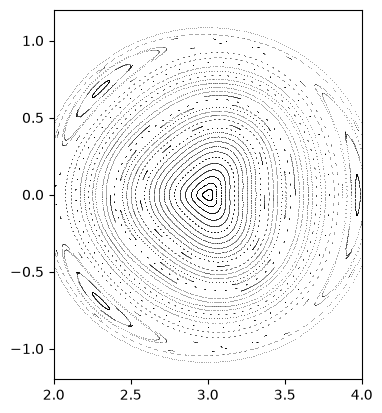

In [6]:
fig, ax = pplot.plot(marker=".", s=0.5, xlim=[2., 4.], ylim=[-1.2, 1.2])
plt.show()

#### Find fixed points

In [8]:
# Find a t-periodic point
fp = FixedPoint(mymap)

guess = np.array([3.7, -0.7])

In [34]:
result = fp.find(
    t=3,                    # t-order fixed points
    guess=guess,
    method="scipy.root"
)

if result is not None:
    print("Fixed point found!")
    print("Coordinates:")
    print(result.coords)
    print("Jacobian:")
    print(result.Jacobian)
    print("Greene's residue:")
    print(result.GreenesResidue)
else:
    print("Fixed-point search failed.")

Fixed point found!
Coordinates:
[[ 3.20169030e+00 -9.80867195e-01]
 [ 2.00409709e+00  6.06245031e-09]
 [ 3.20169031e+00  9.80867184e-01]
 [ 3.20169016e+00 -9.80867216e-01]]
Jacobian:
[[-0.55425196 11.56347935]
 [-0.27320588  3.89572025]]
Greene's residue:
-0.33536707431009694


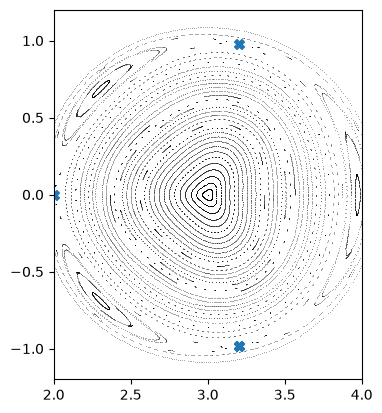

In [39]:
fig, ax = pplot.plot(
    marker=".",
    s=0.5,
    xlim=[2., 4.],
    ylim=[-1.2, 1.2]
)

fp.plot(
    fig=fig,
    ax=ax,
    marker="X",
    s=50,
    plot_all = True
)

plt.show()

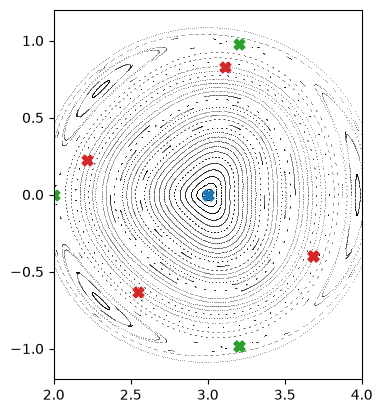

In [33]:
fig, ax = pplot.plot(
    marker=".",
    s=0.5,
    xlim=[2., 4.],
    ylim=[-1.2, 1.2]
)

for t in [1, 2, 3, 4]:
    fp = FixedPoint(mymap)
    result = fp.find(
        t=t,                    # t-order fixed points
        guess=guess,
        method="scipy.root"
    )        

    fp.plot(
        fig=fig,
        ax=ax,
        marker="X",
        s=60
    )

plt.show()


In [30]:
result = fp.find_with_iota(
    n=-2,
    m=3,
    guess=guess,
    method="scipy.root"
)

if result is not None:
    print("Fixed point found!")
    print("Coordinates:")
    print(result.coords)
    print("Jacobian:")
    print(result.Jacobian)
    print("Greene's residue:")
    print(result.GreenesResidue)
else:
    print("Fixed-point search failed.")

Fixed-point search failed.


Exception: A successful call of compute() is needed

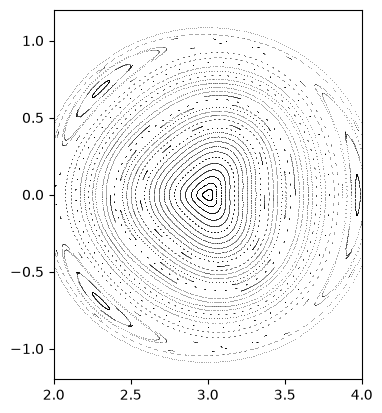

In [31]:
fig, ax = pplot.plot(
    marker=".",
    s=0.5,
    xlim=[2., 4.],
    ylim=[-1.2, 1.2]
)

fp.plot(
    fig=fig,
    ax=ax,
    marker="X",
    s=80
)

plt.show()